# **Customer Churn Prediction**

This project predicts whether a bank customer is likely to leave (churn) based on demographic and account information. Dataset: Churn Modelling Dataset (Kaggle)

## **1- Load and Preview Dataset**

In [11]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
# Load the dataset
df = pd.read_csv("Churn_Modelling.csv")
# Preview the first 5 rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


I loaded the Churn Modelling dataset containing customer demographic and account information. 
The target variable is `Exited`, which indicates whether a customer has churned (1) or stayed (0).

## **2- Clean the dataset**

`Check for Missing Values`

In [12]:
# Check missing values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

`No missing values are present in the dataset. Therefore, no imputation is required.  
All features are ready for preprocessing.`

`Drop Unnecessary Columns`

In [13]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


`Identifier columns were removed to avoid bias in the model and to focus on predictive features.`

## **3- Encode categorical features**

In [14]:
# One-Hot Encoding for Geography 
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Label Encoding for Gender
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


- Geography is one-hot encoded into ``Geography_Germany`` and ``Geography_Spain`` (France dropped as reference). 

`- Gender is label encoded (Male → 1, Female → 0).  `

`This converts categorical features into numeric values so machine learning models can process them.`

## **4- Train a model**

`Define Features and Target`

In [15]:
# Features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

X.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


`Train-Test Split`

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

`Train a Classification Model`

In [17]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model
model = DecisionTreeClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

`Make Predictions`

In [18]:
# Predict on test data
y_pred = model.predict(X_test)

`Model Evaluation`

Decision Tree Accuracy: 0.7845


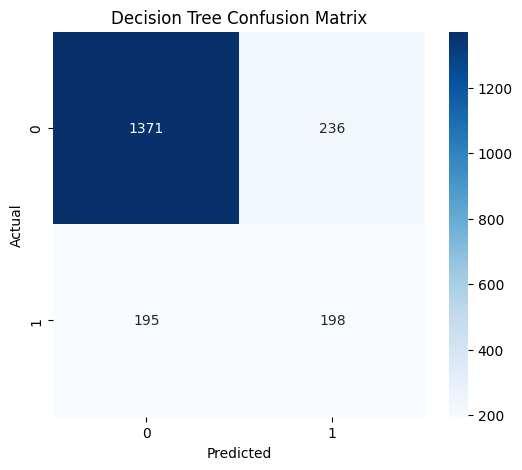

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **5-Feature Importance**

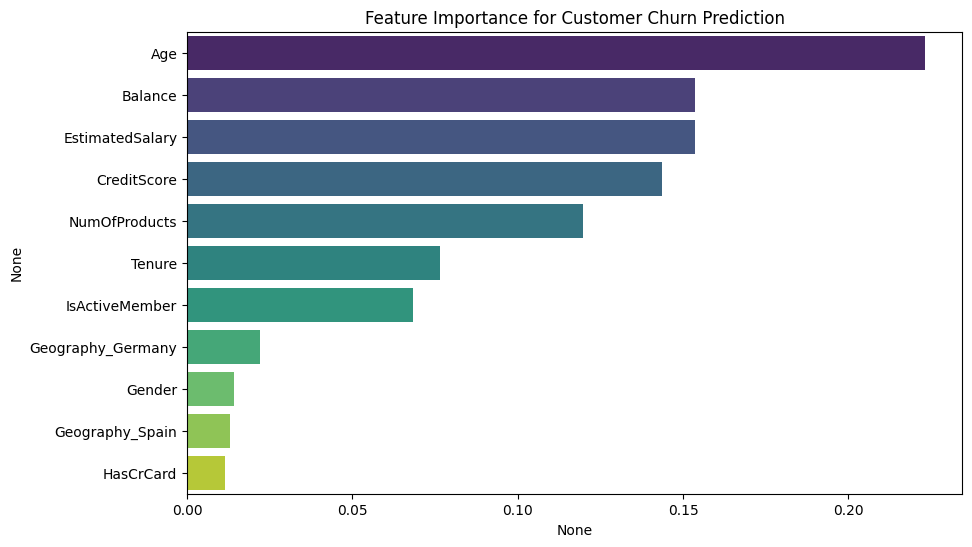

In [20]:
# Feature importance
importances = model.feature_importances_
features = X.columns
feat_importances = pd.Series(importances, index=features).sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importances, y=feat_importances.index, palette="viridis")
plt.title("Feature Importance for Customer Churn Prediction")
plt.show()

`This visualization shows which features influence customer churn the most.`

## **6- Conclusion**

` The Decision Tree model successfully predicts customers likely to leave the bank.`
